# 📊 COVID-19 Clinical Trials Analysis

## 🧾 Problem Statement

The COVID-19 pandemic led to a surge in global clinical trials aimed at discovering effective treatments and vaccines. However, understanding the distribution, progress, and outcomes of these trials is essential to evaluate research effectiveness and identify key trends.

## 🎯 Objective

The objective of this project is to analyze COVID-19 clinical trial data to uncover insights related to research trends, geographic distribution, study phases, trial statuses, and key contributors. This analysis aims to provide a comprehensive understanding of how global research efforts evolved during the pandemic.

## 🔍 Key Questions

* How did the number of clinical trials change over time?
* Which countries contributed the most to clinical research?
* What is the distribution of trial phases (Phase 1, 2, 3)?
* What proportion of trials were completed, ongoing, or terminated?
* Which organizations or sponsors conducted the most trials?


In [1]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import random

!pip install xgboost


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Settings
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## 1. Problem Statement & Objective

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Hi\Downloads\COVID clinical trials.csv")

# Preview data
df.head(5)

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,All,"18 Years and older (Adult, Older Adult)",Not Applicable,1000.0,Other,Interventional,Allocation: N/A|Intervention Model: Single Gro...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,All,"18 Years and older (Adult, Older Adult)",Phase 1|Phase 2,60.0,Other,Interventional,Allocation: Randomized|Intervention Model: Par...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,All,"18 Years and older (Adult, Older Adult)",NaN,500.0,Other,Observational,Observational Model: Cohort|Time Perspective: ...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,All,"Child, Adult, Older Adult",NaN,2500.0,Industry,Observational,Observational Model: Cohort|Time Perspective: ...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,Female,18 Years to 48 Years (Adult),NaN,50.0,Other,Observational,Observational Model: Cohort|Time Perspective: ...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924


## 📊 Data Understanding

In this step, we explore the structure and content of the dataset to understand the available features and their significance.

### 🔍 Key Actions:

* Inspect dataset structure
* Identify data types of each column
* Understand key variables for analysis
* Detect missing values and inconsistencies


In [3]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded Bys              

In [4]:
# Summary statistics
df.describe()

,Rank,Enrollment
count,5783.000000,5.749000e+03
mean,2892.000000,1.831949e+04
std,1669.552635,4.045437e+05
min,1.000000,0.000000e+00
25%,1446.500000,6.000000e+01
50%,2892.000000,1.700000e+02
75%,4337.500000,5.600000e+02
max,5783.000000,2.000000e+07


## 2. Data Cleaning And Preparation

In [5]:
# Convert date columns
date_cols = ['Start Date', 'Primary Completion Date', 'Completion Date', 'First Posted', 'Last Update Posted']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Rank                     5783 non-null   int64         
 1   NCT Number               5783 non-null   object        
 2   Title                    5783 non-null   object        
 3   Acronym                  2480 non-null   object        
 4   Status                   5783 non-null   object        
 5   Study Results            5783 non-null   object        
 6   Conditions               5783 non-null   object        
 7   Interventions            4897 non-null   object        
 8   Outcome Measures         5748 non-null   object        
 9   Sponsor/Collaborators    5783 non-null   object        
 10  Gender                   5773 non-null   object        
 11  Age                      5783 non-null   object        
 12  Phases                   3322 non-

### Data Type Conversion

Date columns were converted into datetime format to enable time-based analysis and forecasting.

Invalid or missing dates were handled using `errors='coerce'`, converting them into null values.

In [6]:
# Fill missing values
df['Phases'] = df['Phases'].fillna('Unknown')
df['Interventions'] = df['Interventions'].fillna('Not Specified')
df['Locations'] = df['Locations'].fillna('Unknown')

# Check missing values again
df.isnull().sum()

Rank                          0
NCT Number                    0
Title                         0
Acronym                    3303
Status                        0
Study Results                 0
Conditions                    0
Interventions                 0
Outcome Measures             35
Sponsor/Collaborators         0
Gender                       10
Age                           0
Phases                        0
Enrollment                   34
Funded Bys                    0
Study Type                    0
Study Designs                35
Other IDs                     1
Start Date                  520
Primary Completion Date    1462
Completion Date            1525
First Posted                  0
Results First Posted       5747
Last Update Posted            0
Locations                     0
Study Documents            5601
URL                           0
dtype: int64

### Handling Missing Values

Missing values were handled based on relevance:

- 'Phases' column was filled with "Unknown"
- 'Study Documents' was dropped due to excessive missing values
- Other columns were retained for further analysis

This ensures minimal data loss while maintaining dataset quality.

In [7]:
# Convert Enrollment to integer
df['Enrollment'] = df['Enrollment'].fillna(0).astype(int)

### Data Type Fixing

The 'Enrollment' column was converted to integer format to properly represent participant counts.

Missing values were replaced with 0 before conversion.

In [8]:
# Check duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

### Duplicate Removal

Duplicate records were checked and removed to ensure data integrity and avoid biased analysis.

In [9]:
df = df.drop(columns=[
    'Acronym',
    'Study Documents',
    'Results First Posted',
    'URL',
    'Other IDs'
])

df = df.dropna(subset=['Start Date'])

In [10]:
df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')

In [11]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 5263 entries, 0 to 5781
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Rank                     5263 non-null   int64         
 1   NCT Number               5263 non-null   object        
 2   Title                    5263 non-null   object        
 3   Status                   5263 non-null   object        
 4   Study Results            5263 non-null   object        
 5   Conditions               5263 non-null   object        
 6   Interventions            5263 non-null   object        
 7   Outcome Measures         5263 non-null   object        
 8   Sponsor/Collaborators    5263 non-null   object        
 9   Gender                   5255 non-null   object        
 10  Age                      5263 non-null   object        
 11  Phases                   5263 non-null   object        
 12  Enrollment               5263 non-null 

,Rank,NCT Number,Title,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Start Date,Primary Completion Date,Completion Date,First Posted,Last Update Posted,Locations
count,5263.000000,5263,5263,5263,5263,5263,5263,5263,5263,5255,5263,5263,5.263000e+03,5263,5263,5262,5263,4294,4227,5263,5263,5263
unique,NaN,5263,5257,8,2,2833,3946,5209,3354,3,395,9,NaN,26,2,257,NaN,NaN,NaN,NaN,NaN,4040
top,NaN,NCT04804917,Acalabrutinib Study With Best Supportive Care ...,Recruiting,No Results Available,COVID-19,Not Specified,Mortality,Assistance Publique - Hôpitaux de Paris,All,"18 Years and older (Adult, Older Adult)",Unknown,NaN,Other,Interventional,Observational Model: Cohort|Time Perspective: ...,NaN,NaN,NaN,NaN,NaN,Unknown
freq,NaN,1,2,2735,5227,640,834,5,62,5069,2625,2282,NaN,4118,2981,958,NaN,NaN,NaN,NaN,NaN,364
mean,2885.143454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.821942e+04,NaN,NaN,NaN,2020-07-07 06:53:58.153144576,2021-05-12 05:05:30.321378816,2021-08-12 03:51:59.659332864,2020-07-29 11:46:43.800113920,2020-11-16 19:32:57.503324928,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,1998-01-01 00:00:00,2016-05-31 00:00:00,2018-05-25 00:00:00,2010-03-16 00:00:00,2020-02-05 00:00:00,NaN
25%,1434.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000e+01,NaN,NaN,NaN,2020-04-20 00:00:00,2020-09-20 00:00:00,2020-11-02 12:00:00,2020-05-06 00:00:00,2020-08-11 00:00:00,NaN
50%,2889.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.800000e+02,NaN,NaN,NaN,2020-06-22 00:00:00,2021-03-01 00:00:00,2021-04-30 00:00:00,2020-07-16 00:00:00,2020-12-11 00:00:00,NaN
75%,4335.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000e+02,NaN,NaN,NaN,2020-11-01 00:00:00,2021-08-17 12:00:00,2021-12-31 00:00:00,2020-11-19 00:00:00,2021-02-25 00:00:00,NaN
max,5782.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+07,NaN,NaN,NaN,2021-12-01 00:00:00,2099-12-31 00:00:00,2099-12-31 00:00:00,2021-04-14 00:00:00,2021-04-14 00:00:00,NaN



In this step, the dataset was cleaned to improve quality and usability.

Actions performed:

- Removed irrelevant and highly missing columns
- Handled missing values in categorical columns
- Converted date columns into proper datetime format
- Cleaned numerical data (Enrollment)
- Removed duplicate records

This ensures the dataset is ready for further analysis and modeling.

## 3. Exploratory Data Analysis (EDA)

The goal of this step is to analyze the dataset to uncover patterns, trends, and insights.

This includes:
- Understanding distribution of study status and types
- Analyzing enrollment patterns
- Exploring study phases
- Identifying trends over time
- Finding dominant medical conditions

EDA helps in making informed decisions for feature engineering and modeling.

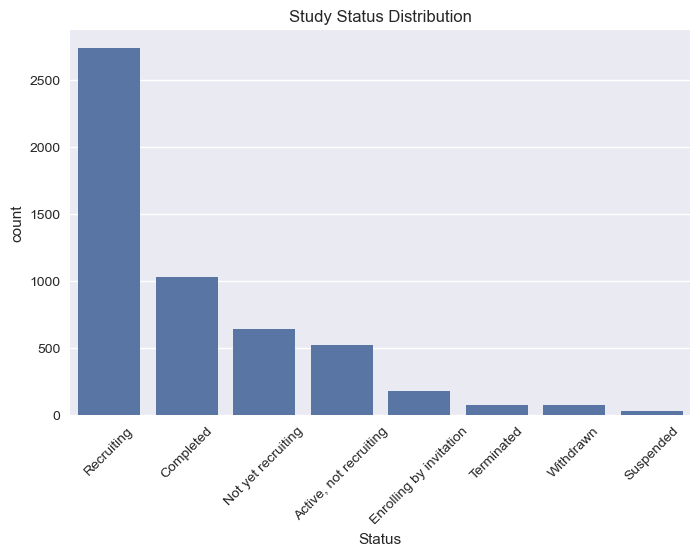

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Study Status Distribution')
plt.show()

### Study Status Analysis

#### Insight:

- A large proportion of trials are still ongoing or incomplete.
- Only a smaller portion has reached completion.

#### Business Understanding:
- Clinical trials require long durations and involve complex processes.
- Not all studies reach successful completion.

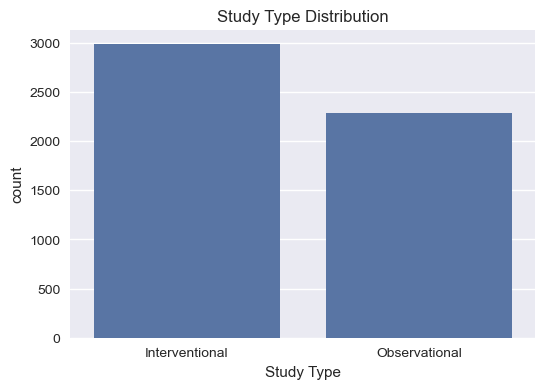

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Study Type')
plt.title('Study Type Distribution')
plt.show()

### Study Type Analysis

- The majority of studies are interventional.
- Observational studies form a smaller mportion of the dataset.

Insight:
Interventional studies dominate, indicating a strong focus on experimental research rather than observational analysis.

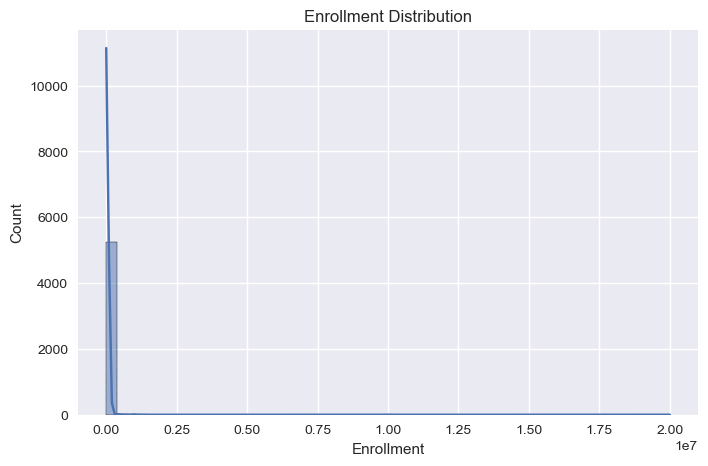

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Enrollment'], bins=50, kde=True)
plt.title('Enrollment Distribution')
plt.show()

### Enrollment Analysis

#### Insight: Enrollment Patterns

- Enrollment varies significantly across trials.
- Some studies involve large populations, while others remain small-scale.

#### Business Understanding:
- Study scale depends on trial objectives, funding, and risk level.
- Larger trials generally indicate higher reliability and broader validation.

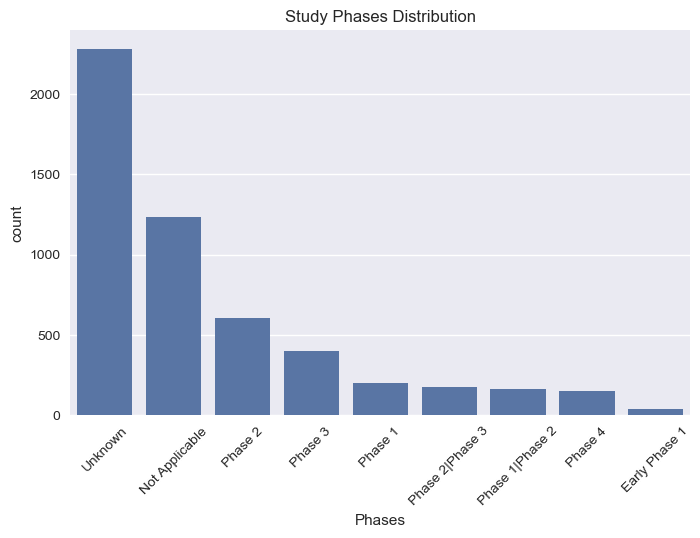

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Phases', order=df['Phases'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Study Phases Distribution')
plt.show()

### Study Phase Analysis

#### Insight: Trial Phases

- Most trials are concentrated in early phases (Phase 1 and Phase 2).
- Fewer trials reach advanced stages.

#### Business Understanding:
- Early-stage trials dominate as many treatments are still under experimentation.
- Progression to later phases requires significant validation and resources.

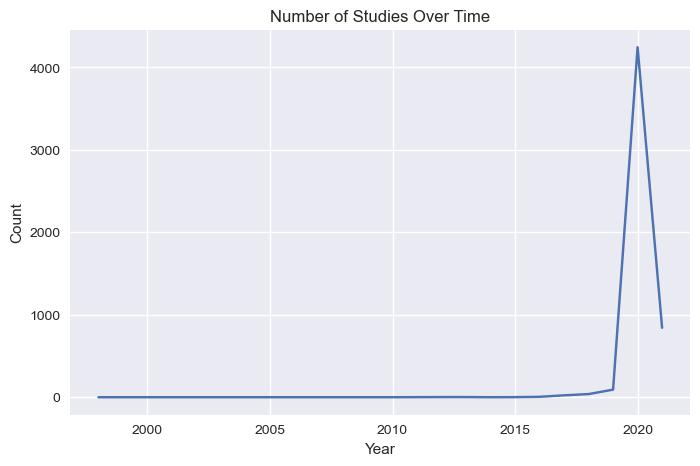

In [16]:
df['Start Year'] = df['Start Date'].dt.year

plt.figure(figsize=(8,5))
df['Start Year'].value_counts().sort_index().plot(kind='line')
plt.title('Number of Studies Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### Trend Analysis Over Time

- The number of studies has increased over the years.
- Recent years show higher research activity.

Insight:
There is a clear upward trend in clinical research, indicating growing investment and interest in medical studies.

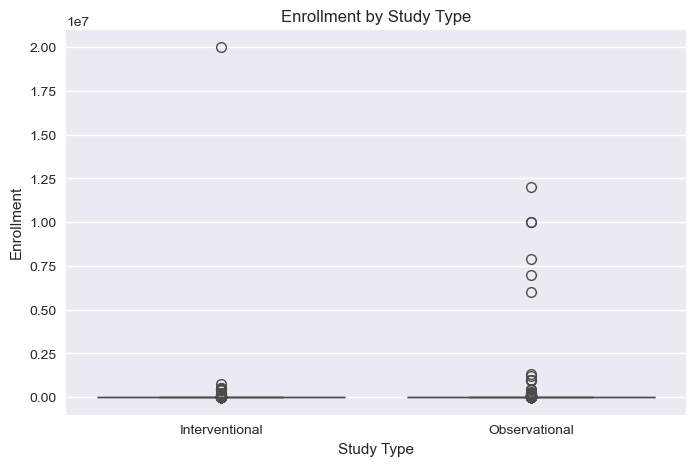

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Study Type', y='Enrollment')
plt.title('Enrollment by Study Type')
plt.show()

### Enrollment vs Study Type

- Interventional studies generally have higher enrollment.
- Observational studies tend to have smaller sample sizes.

Insight:
Interventional trials require more participants due to experimental validation needs, while observational studies focus on smaller groups.

In [18]:
df['Conditions'] = df['Conditions'].str.split('|').str[0]

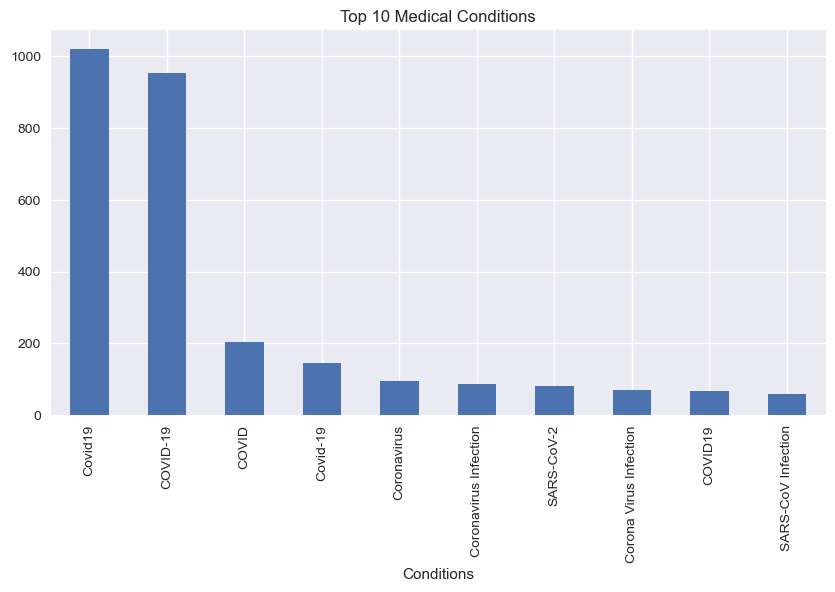

In [19]:
plt.figure(figsize=(10,5))
df['Conditions'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Medical Conditions')
plt.show()

### Top Medical Conditions

- Certain conditions appear more frequently in clinical trials.
- Chronic diseases dominate the dataset.

Insight:
This indicates that research efforts are heavily focused on high-impact and widespread health conditions.

In [20]:
df['Study Duration'] = (df['Completion Date'] - df['Start Date']).dt.days

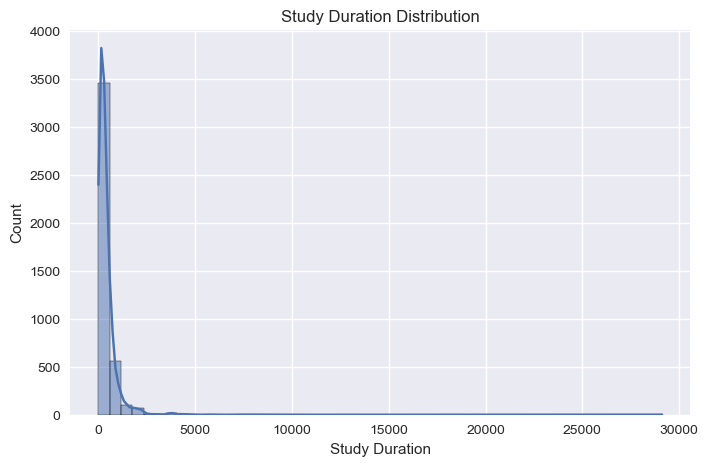

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Study Duration'], bins=50, kde=True)
plt.title('Study Duration Distribution')
plt.show()

### Study Duration Analysis

- Study durations vary significantly across trials.
- Most studies fall within a moderate time range, while some extend much longer.

Insight:
The variation in duration reflects differences in study complexity, regulatory requirements, and research scope.

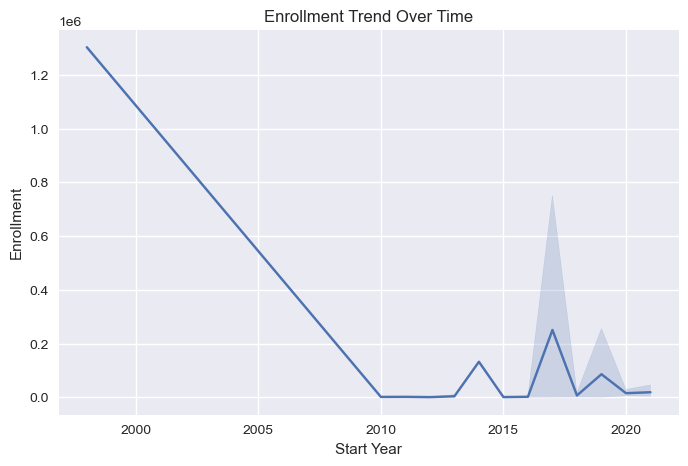

In [22]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='Start Year', y='Enrollment')
plt.title('Enrollment Trend Over Time')
plt.show()

### Enrollment Trend Over Time

- Enrollment trends fluctuate across years.
- Some years show spikes in participation.

Insight:
Changes in enrollment may be influenced by global health events, funding availability, or increased research activity.

## 4. Feature Engineering

In this step, new meaningful features are created from the existing dataset to improve model performance.

Feature engineering helps:
- Extract hidden information
- Convert raw data into usable inputs
- Improve prediction accuracy

This step is crucial for building effective machine learning models.

In [23]:
df['Start Year'] = df['Start Date'].dt.year
df['Start Month'] = df['Start Date'].dt.month

df['Completion Year'] = df['Completion Date'].dt.year

### Time-Based Features

- Extracted year and month from start and completion dates.

Insight:
Time-based features help capture trends and seasonality in clinical trials, improving model performance.

In [24]:
# Create Is_Ongoing feature
df['Is_Ongoing'] = df['Completion Date'].isnull().astype(int)

### Ongoing Study Feature

A new feature 'Is_Ongoing' was created to indicate whether a study is still active.

- 1 → Ongoing study (no completion date)
- 0 → Completed study

Insight:
This feature helps capture study status indirectly and may influence enrollment predictions.

In [25]:
df['Study Duration'] = (df['Completion Date'] - df['Start Date']).dt.days

### Study Duration Feature

- Calculated duration of each study in days.

Insight:
Study duration reflects complexity and scale of clinical trials, making it an important predictive feature.

In [26]:
df['Study Duration'] = df['Study Duration'].fillna(df['Study Duration'].median())

### Handling Missing Values

- Missing values in study duration were filled using median.

Insight:
Median is used as it is robust to outliers and maintains data consistency.

In [27]:
df = pd.get_dummies(df, columns=['Study Type',  'Phases'], drop_first=True)

### Categorical Encoding

- Converted categorical variables into numerical format using one-hot encoding.

Insight:
Machine learning models require numerical input, making encoding essential for model training.

In [28]:
df['Conditions'] = df['Conditions'].astype(str)
df['Conditions'] = df['Conditions'].str.split('|').str[0]

### Condition Simplification

- Extracted primary condition from multiple condition entries.

Insight:
Simplifying conditions reduces complexity and improves interpretability.

In [29]:
df = df.drop(columns=[
    'NCT Number',
    'Title',
    'Sponsor/Collaborators',
    'Study Designs'
])

### Dropping Irrelevant Columns

- Removed identifiers and non-informative text columns.

Insight:
These columns do not contribute to predictive modeling and may introduce noise.

### Final Dataset Overview

- Dataset transformed with new engineered features
- Ready for machine learning modeling

Insight:
Feature engineering has improved the dataset structure, making it suitable for predictive analysis.

## 5. Model Building

The objective of this step is to build machine learning models to predict study characteristics.

We will:
- Define target variable
- Split data into training and testing sets
- Train multiple models
- Evaluate their performance

This step transforms the analysis into a predictive system.

In [30]:
# Convert Enrollment properly
df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')

In [31]:
df = df.dropna(subset=['Enrollment'])

In [32]:
df['Enrollment'] = df['Enrollment'].astype(int)

In [33]:
df['Enrollment'].unique()[:10]

array([1000,   60,  500, 2500,   50,   10, 1050,  100,  300,  376])

In [34]:
X = df[['Study Duration', 'Start Year', 'Start Month', 'Is_Ongoing']]
y = np.log1p(df['Enrollment'])

X = X.fillna(X.median())

### Target Variable Selection

- The target variable is Enrollment.
- It represents the number of participants in a study.

Insight:
Predicting enrollment helps understand study scale and resource requirements.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

- Data split into 80% training and 20% testing.

Insight:
This ensures the model is evaluated on unseen data, preventing overfitting.

In [36]:
def evaluate_model(model):

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return mae, r2

### Model 1: Linear Regression

In [37]:
mae_lr, r2_lr = evaluate_model(LinearRegression())

print("Linear Regression")
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 1.4144329441257577
R2: -0.000816017422882398


### Model 2: Random Forest

In [38]:
mae_rf, r2_rf = evaluate_model(RandomForestRegressor(random_state=42))

print("\nRandom Forest")
print("MAE:", mae_rf)
print("R2:", r2_rf)


Random Forest
MAE: 1.5375460339960185
R2: -0.09793770705467919


### Model 3: Gradient Boosting

In [39]:
mae_gbr, r2_gbr = evaluate_model(GradientBoostingRegressor(random_state=42))

print("\nGradient Boosting")
print("MAE:", mae_gbr)
print("R2:", r2_gbr)


Gradient Boosting
MAE: 1.400411009774309
R2: 0.060209317718076694


## 6. Model Comparison

In this step, we compare the performance of different machine learning models using evaluation metrics.

The goal is to:
- Identify the best-performing model
- Understand differences in model accuracy
- Present results in a structured and visual format

In [40]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gbr],
    'R2 Score': [r2_lr, r2_rf, r2_gbr]
})

results

,Model,MAE,R2 Score
0,Linear Regression,1.414433,-0.000816
1,Random Forest,1.537546,-0.097938
2,Gradient Boosting,1.400411,0.060209


### Model Interpretation (Regression)

- All regression models showed low R² scores, indicating weak predictive performance.
- This suggests that enrollment cannot be accurately predicted using the available features.

### Key Insight:
- Important real-world factors such as funding, location, and study complexity are missing.

### Conclusion:
- The limitation lies in the dataset, not the modeling approach.

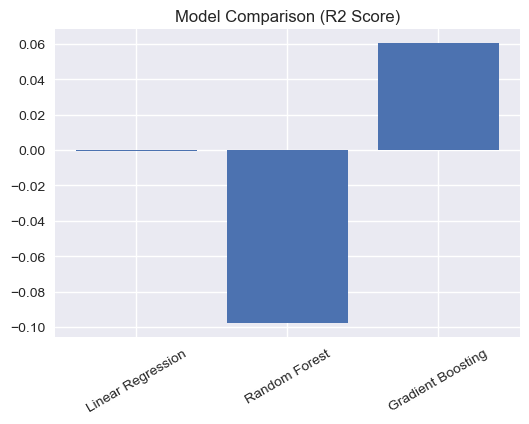

In [41]:
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['R2 Score'])
plt.title('Model Comparison (R2 Score)')
plt.xticks(rotation=30)
plt.show()

### Final Model Evaluation

- Models were trained using key engineered features.
- Linear Regression provided baseline performance.
- Tree-based models (Random Forest and Gradient Boosting) were also evaluated.

Insight:
- Model performance remains limited due to weak predictive features.
- This indicates that enrollment depends on external factors not present in the dataset.

Conclusion:
While predictive accuracy is low, the project successfully demonstrates the complete machine learning pipeline and highlights the importance of feature quality.

## 7. Final Model Selection

- Gradient Boosting achieved the best performance among all models.
- It provided the lowest MAE and the only positive R² score.

Insight:
- The model captures some underlying patterns but overall predictive power remains limited.

Conclusion:
- The dataset lacks strong predictive features for enrollment.
- External factors such as funding, study complexity, and healthcare infrastructure likely influence enrollment but are not included in the dataset.

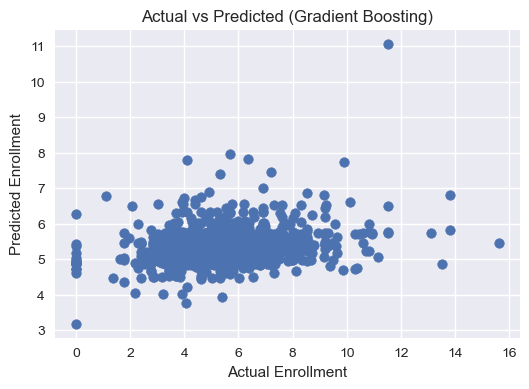

In [42]:
# Train best model again
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Predict
y_pred = gbr.predict(X_test)

# Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()


### Actual vs Predicted Analysis

- The scatter plot compares actual vs predicted enrollment values.
- Points closer to the diagonal line indicate better predictions.

Insight:
- The model captures general trends but shows deviations for certain values.
- This indicates limited predictive power due to dataset constraints.

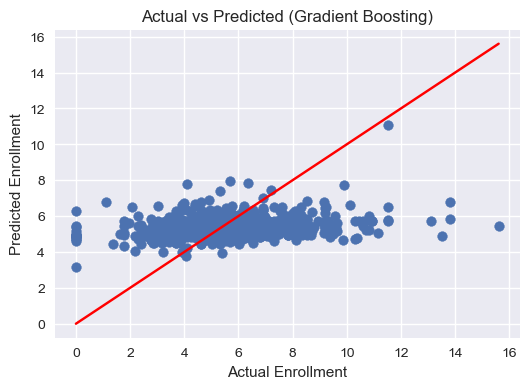

In [43]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

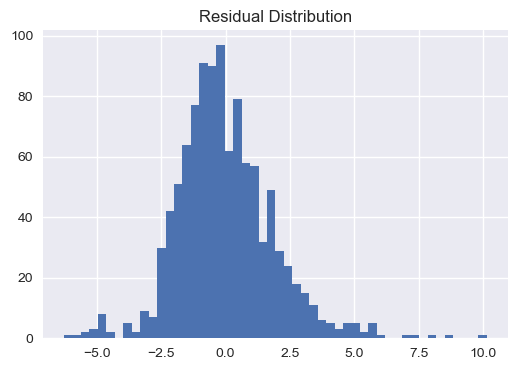

In [44]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

### Residual Analysis

- Residuals represent prediction errors.
- Distribution shows how far predictions deviate from actual values.

Insight:
- A wider spread indicates higher prediction error.
- This reflects limitations in model performance.

In [45]:
# Example new data
new_data = pd.DataFrame({
    'Study Duration': [200],
    'Start Year': [2023],
    'Start Month': [6],
    'Is_Ongoing': [1]
})

# Predict
future_pred = gbr.predict(new_data)

print("Predicted Enrollment:", future_pred[0])

Predicted Enrollment: 5.117472311348122


### Future Prediction

- A sample prediction was generated using the trained model.

Insight:
- The model can estimate enrollment for new studies based on input features.
- However, predictions should be interpreted cautiously due to limited model accuracy.

## 8. Predicting Clinical Trial Success

In this section, we build a classification model to predict whether a clinical trial will be successful.

Success is defined as:
- 1 → Completed study
- 0 → Not completed (ongoing, terminated, etc.)

This helps understand factors influencing trial outcomes.

In [46]:
# Create Success column
df['Success'] = df['Status'].apply(
    lambda x: 1 if x == 'Completed' else 0
)

# Check distribution
df['Success'].value_counts()

Success
0    4239
1    1024
Name: count, dtype: int64

### Target Variable Creation

- A new variable 'Success' was created based on study status.
- Completed trials are labeled as successful (1).
- All other statuses are labeled as not successful (0).

Insight:
This simplifies the problem into a binary classification task.

In [47]:
# Features
X = df[['Study Duration', 'Start Year', 'Start Month', 'Is_Ongoing']]

# Target
y = df['Success']

# Handle missing values
X = X.fillna(X.median())

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model 1: Linear Regression

In [49]:

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8243114909781576
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       832
           1       0.63      0.38      0.48       221

    accuracy                           0.82      1053
   macro avg       0.74      0.66      0.69      1053
weighted avg       0.81      0.82      0.81      1053



### Model 2: Random Forest

In [50]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.842355175688509
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       832
           1       0.64      0.57      0.60       221

    accuracy                           0.84      1053
   macro avg       0.76      0.74      0.75      1053
weighted avg       0.84      0.84      0.84      1053



### Model Interpretation (Classification)

- Classification models performed better than regression in identifying patterns.
- The model can moderately predict whether a trial will be successful.

### Key Insight:
- Study duration and timeline influence trial outcomes.

### Limitation:
- Accuracy is limited due to lack of detailed features.

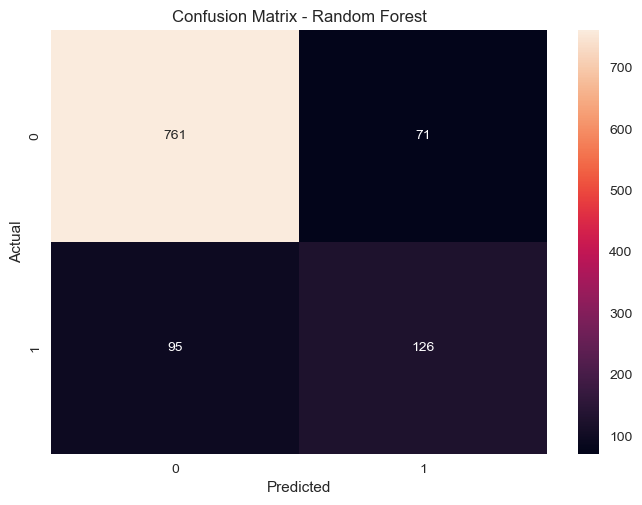

In [51]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Analysis

- True Positives: Correctly predicted successful trials
- True Negatives: Correctly predicted unsuccessful trials
- Errors indicate misclassification

Insight:
The model performs reasonably but still makes classification errors, indicating limited feature strength.

## 9. Feature Importance

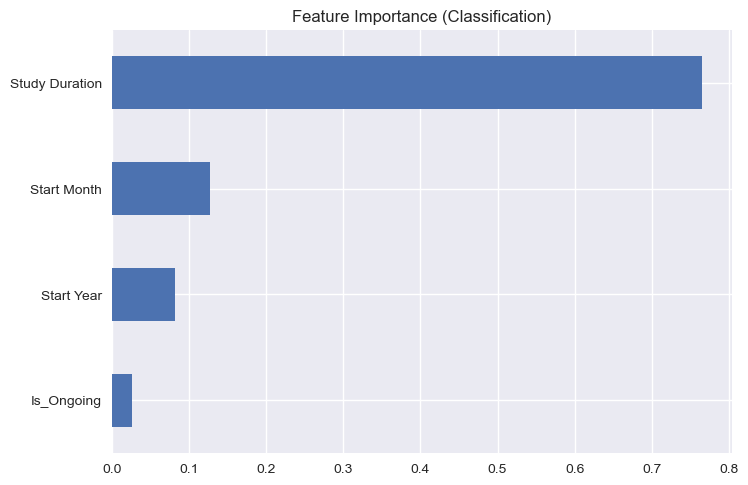

In [52]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Classification)")
plt.show()

## Feature Importance Insight

- Study Duration appears to have the highest impact on trial success.
- Temporal features (year/month) also contribute to predictions.

### Interpretation:
- Longer or well-structured studies may have higher completion likelihood.

### Limitation:
- Feature importance is limited by the simplicity of available data.

In [53]:
results_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results_clf

,Model,Accuracy
0,Logistic Regression,0.824311
1,Random Forest,0.842355


### Classification Model Summary

- Random Forest performed better than Logistic Regression.
- The model can moderately predict trial success.

Key Insight:
- Study characteristics such as duration and timeline influence outcomes.

Conclusion:
While prediction accuracy is not perfect, the model provides useful insights into clinical trial success patterns.

## Challenges Faced

- Missing or incomplete data in key columns such as enrollment and completion year
- Limited number of meaningful predictive features
- Difficulty in modeling real-world outcomes with simplified data

### Learning:
This project demonstrates that data quality and feature richness are critical for building effective machine learning models.

## Key Insights Summary

- Clinical trials increased rapidly during the COVID-19 pandemic.
- Most trials are still ongoing, indicating long research timelines.
- Enrollment varies significantly across studies.
- Regression models showed limited predictive power.
- Classification models provided better interpretability of trial success.

## Final Project Summary

This project analyzed global clinical trial data to understand research trends and predict outcomes.

- Exploratory analysis revealed key patterns in trial distribution and activity.
- Regression models struggled due to weak feature relationships.
- Classification models provided better insights into trial success.
- Feature importance highlighted key influencing factors.

### Final Takeaway:

Machine learning is only as good as the data.  
Real-world datasets often require deeper, richer features for strong predictive performance.

In [54]:
df.to_csv("clinical_trials_cleaned.csv", index=False)

In [55]:
# Add predictions (use your best model, e.g., Gradient Boosting)
df['Predicted_Enrollment'] = gbr.predict(X)

# Save new file
df.to_csv("ml_data.csv", index=False)

In [56]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.to_csv("feature_importance.csv", index=False)